In [34]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime

In [35]:
#Train dataset and test dataset
train_dataset = torchvision.datasets.FashionMNIST(root='.', train=True, transform=transforms.ToTensor(), download=True)
test_dataset = torchvision.datasets.FashionMNIST(root='.', train=False, transform=transforms.ToTensor(), download=True)

In [36]:
#Data attributes
print(f'Shape of dataset {train_dataset.data.shape}')
print(f'Max {train_dataset.data.max()}')
print(f'Targets {train_dataset.targets}')
print(f'Number of classes: {len(set(train_dataset.targets.numpy()))}')

Shape of dataset torch.Size([60000, 28, 28])
Max 255
Targets tensor([9, 0, 0,  ..., 3, 0, 5])
Number of classes: 10


In [37]:
K = len(set(train_dataset.targets.numpy()))
K

10

In [38]:
class CNN(nn.Module):
    def __init__(self, K):
        super(CNN, self).__init__()
        self.conv_layers = nn.Sequential(
            nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, stride=2),
            nn.ReLU(),
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, stride=2),
            nn.ReLU(),
            nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, stride=2),
            nn.ReLU()
        )

        self.dense_layers = nn.Sequential(
            nn.Dropout(0.2),
            nn.Linear(128 * 2 * 2, 512),  # adjust this if input image size changes
            nn.ReLU(),
            nn.Linear(512, K)
        )

    def forward(self, X):
        out = self.conv_layers(X)
        out = out.view(out.size(0), -1)
        out = self.dense_layers(out)
        return out

In [39]:
model = CNN(K)

In [40]:
#Same model but with flatten
#model = nn.Sequential(
#    nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, stride=2),
#    nn.ReLU(),
#    nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, stride=2),
#    nn.ReLU(),
#    nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, stride=2),
#    nn.ReLU(),
#    nn.Flatten(),
#    nn.Dropout(0.2),
#    nn.Linear(128*2*2, 512),
#    nn.ReLU(),
#    nn.Linear(512, K)
#   
#)

In [41]:
device = torch.device('mps')
model.to(device)

CNN(
  (conv_layers): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(2, 2))
    (1): ReLU()
    (2): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2))
    (3): ReLU()
    (4): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2))
    (5): ReLU()
  )
  (dense_layers): Sequential(
    (0): Dropout(p=0.2, inplace=False)
    (1): Linear(in_features=512, out_features=512, bias=True)
    (2): ReLU()
    (3): Linear(in_features=512, out_features=10, bias=True)
  )
)

In [42]:
#Loss and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters())

In [43]:
#Data loader
batch_size = 128

train_loader = torch.utils.data.DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)
test_loader = torch.utils.data.DataLoader(dataset=test_dataset, batch_size=batch_size, shuffle=False)

In [44]:
#Training loop
def batch_gd(model, criterion, optimizer, train_loader, test_loader, epochs):
    train_losses = np.zeros(epochs)
    test_losses = np.zeros(epochs)
    
    for i in range(epochs):
        model.train()
        t0 = datetime.now()
        train_loss = []
        
        for inputs, targets in train_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            
            #Zero the parameters grad
            optimizer.zero_grad()
            
            #Forward pass
            outputs = model(inputs)
            loss = criterion(outputs, targets) 
            loss.backward()
            optimizer.step()
            train_loss.append(loss.item())
            
        train_loss = np.mean(train_loss)
        
        model.eval()
        test_loss = []
        
        for inputs, targets in test_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            
            #Forward pass
            outputs = model(inputs)
            loss = criterion(outputs, targets) 
            test_loss.append(loss.item())
            
        test_loss = np.mean(test_loss)
        
        #Save losses
        train_losses[i] = train_loss
        test_losses[i] = test_loss
        
        dt = datetime.now() - t0
        
        print(f'Epoch {i+1}/{epochs}, Train loss: {train_loss:.4f}, Test loss: {test_loss:.4f}, Duration: {dt}')
    return train_losses, test_losses 

In [45]:
train_losses, test_losses = batch_gd(model, criterion, optimizer, train_loader, test_loader, epochs=15)

Epoch 1/15, Train loss: 0.6519, Test loss: 0.4866, Duration: 0:00:04.232915
Epoch 2/15, Train loss: 0.4337, Test loss: 0.4048, Duration: 0:00:04.577905
Epoch 3/15, Train loss: 0.3762, Test loss: 0.3676, Duration: 0:00:04.403987
Epoch 4/15, Train loss: 0.3414, Test loss: 0.3505, Duration: 0:00:04.478739
Epoch 5/15, Train loss: 0.3127, Test loss: 0.3470, Duration: 0:00:04.411207
Epoch 6/15, Train loss: 0.2947, Test loss: 0.3123, Duration: 0:00:04.440131
Epoch 7/15, Train loss: 0.2747, Test loss: 0.3181, Duration: 0:00:04.404651
Epoch 8/15, Train loss: 0.2565, Test loss: 0.2968, Duration: 0:00:04.422333
Epoch 9/15, Train loss: 0.2380, Test loss: 0.2914, Duration: 0:00:04.341287
Epoch 10/15, Train loss: 0.2242, Test loss: 0.2841, Duration: 0:00:04.379181
Epoch 11/15, Train loss: 0.2141, Test loss: 0.2802, Duration: 0:00:04.461990
Epoch 12/15, Train loss: 0.1986, Test loss: 0.2814, Duration: 0:00:04.427178
Epoch 13/15, Train loss: 0.1902, Test loss: 0.2869, Duration: 0:00:04.506859
Epoch 14

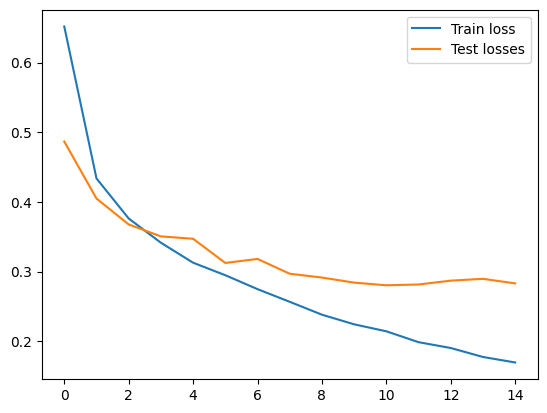

In [46]:
plt.plot(train_losses, label = 'Train loss')
plt.plot(test_losses, label = 'Test losses')
plt.legend()
plt.show()

In [47]:
# Evaluate model accuracy on training and test sets

# -------- Training Accuracy --------
n_correct = 0
n_total = 0

for inputs, targets in train_loader:
    # Move data to device (CPU or GPU)
    inputs, targets = inputs.to(device), targets.to(device)

    # Get model predictions
    outputs = model(inputs)

    # Get predicted class (highest score)
    _, predictions = torch.max(outputs, 1)

    # Count correct predictions
    n_correct += (predictions == targets).sum().item()
    n_total += targets.shape[0]

# Calculate training accuracy
train_acc = n_correct / n_total

# -------- Testing Accuracy --------
n_correct = 0
n_total = 0

for inputs, targets in test_loader:
    inputs, targets = inputs.to(device), targets.to(device)
    outputs = model(inputs)
    _, predictions = torch.max(outputs, 1)
    n_correct += (predictions == targets).sum().item()
    n_total += targets.shape[0]

# Calculate test accuracy
test_acc = n_correct / n_total

# Print results
print(f'Train acc: {train_acc:.4f}, Test acc: {test_acc:.4f}')


Train acc: 0.9595, Test acc: 0.9059


In [48]:
# Plot confusion matrix for classification results
from sklearn.metrics import confusion_matrix
import itertools
import matplotlib.pyplot as plt
import numpy as np

def plot_confusion_matrix(cm, classes, normalize=False, title='Confusion Matrix', cmap=plt.cm.Blues):
    """
    Plots a confusion matrix.

    Parameters:
    - cm: confusion matrix (2D array)
    - classes: list of class labels
    - normalize: whether to normalize values
    - title: title of the plot
    - cmap: color map used for the plot
    """
    
    # Normalize the matrix if requested
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print('Normalized confusion matrix')
    else:
        print('Confusion matrix without normalization')

    print(cm)

    # Display the matrix as an image
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()

    # Set up tick marks and labels
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    # Format each cell
    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment='center',
                 color='white' if cm[i, j] > thresh else 'black')

    # Final layout settings
    plt.tight_layout()
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.show()


Confusion matrix without normalization
[[867   1  23  20   2   1  79   0   7   0]
 [  2 978   0  14   3   0   2   0   1   0]
 [ 20   1 859   7  45   0  65   0   3   0]
 [ 10   5  19 904  42   0  17   0   3   0]
 [  0   1  53  12 854   0  79   0   1   0]
 [  1   0   0   1   0 973   0  21   0   4]
 [106   0  58  26  77   0 721   0  12   0]
 [  0   0   0   0   0  13   0 965   0  22]
 [  2   0   6   0   3   1   3   2 982   1]
 [  1   0   0   0   0   9   0  34   0 956]]


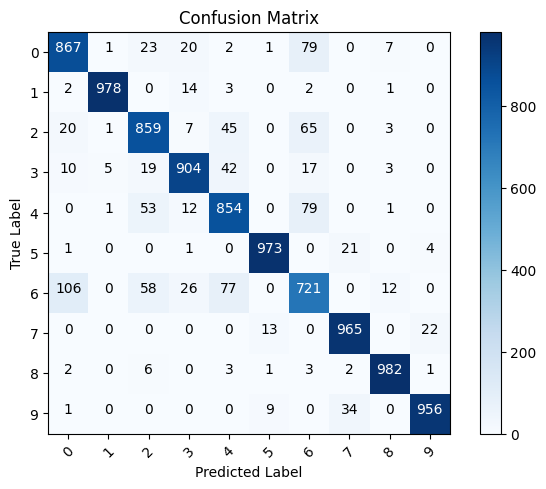

In [49]:
x_test = test_dataset.data.numpy()
y_test = test_dataset.targets.numpy()
p_test = np.array([])

for inputs, targets in test_loader:
    inputs, targets = inputs.to(device), targets.to(device)
    
    #Forward pass
    outputs = model(inputs)
    
    #Predictions 
    _, predictions = torch.max(outputs, 1)
    
    #Update p_test
    p_test = np.concatenate((p_test, predictions.cpu().numpy()))
    
cm = confusion_matrix(y_test, p_test)
plot_confusion_matrix(cm, list(range(10)))

CIFAR dataset

In [50]:
import torch.nn.functional as F

In [103]:
transformer_train = torchvision.transforms.Compose([
    #torchvision.transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.2),
    transforms.RandomCrop(32, padding=4),
    torchvision.transforms.RandomHorizontalFlip(p=0.5),
    #torchvision.transforms.RandomRotation(degrees=15),
    torchvision.transforms.RandomAffine(0, translate=(0.1, 0.1)),
    #torchvision.transforms.RandomPerspective(),
    transforms.ToTensor()])

train_dataset = torchvision.datasets.CIFAR10(root = '.', train= True, transform=transformer_train, download=True)
test_dataset = torchvision.datasets.CIFAR10(root = '.', train= False, transform=transforms.ToTensor(), download=True)

In [104]:
train_dataset.targets

[6,
 9,
 9,
 4,
 1,
 1,
 2,
 7,
 8,
 3,
 4,
 7,
 7,
 2,
 9,
 9,
 9,
 3,
 2,
 6,
 4,
 3,
 6,
 6,
 2,
 6,
 3,
 5,
 4,
 0,
 0,
 9,
 1,
 3,
 4,
 0,
 3,
 7,
 3,
 3,
 5,
 2,
 2,
 7,
 1,
 1,
 1,
 2,
 2,
 0,
 9,
 5,
 7,
 9,
 2,
 2,
 5,
 2,
 4,
 3,
 1,
 1,
 8,
 2,
 1,
 1,
 4,
 9,
 7,
 8,
 5,
 9,
 6,
 7,
 3,
 1,
 9,
 0,
 3,
 1,
 3,
 5,
 4,
 5,
 7,
 7,
 4,
 7,
 9,
 4,
 2,
 3,
 8,
 0,
 1,
 6,
 1,
 1,
 4,
 1,
 8,
 3,
 9,
 6,
 6,
 1,
 8,
 5,
 2,
 9,
 9,
 8,
 1,
 7,
 7,
 0,
 0,
 6,
 9,
 1,
 2,
 2,
 9,
 2,
 6,
 6,
 1,
 9,
 5,
 0,
 4,
 7,
 6,
 7,
 1,
 8,
 1,
 1,
 2,
 8,
 1,
 3,
 3,
 6,
 2,
 4,
 9,
 9,
 5,
 4,
 3,
 6,
 7,
 4,
 6,
 8,
 5,
 5,
 4,
 3,
 1,
 8,
 4,
 7,
 6,
 0,
 9,
 5,
 1,
 3,
 8,
 2,
 7,
 5,
 3,
 4,
 1,
 5,
 7,
 0,
 4,
 7,
 5,
 5,
 1,
 0,
 9,
 6,
 9,
 0,
 8,
 7,
 8,
 8,
 2,
 5,
 2,
 3,
 5,
 0,
 6,
 1,
 9,
 3,
 6,
 9,
 1,
 3,
 9,
 6,
 6,
 7,
 1,
 0,
 9,
 5,
 8,
 5,
 2,
 9,
 0,
 8,
 8,
 0,
 6,
 9,
 1,
 1,
 6,
 3,
 7,
 6,
 6,
 0,
 6,
 6,
 1,
 7,
 1,
 5,
 8,
 3,
 6,
 6,
 8,
 6,
 8,
 4,
 6,
 6,


In [105]:
K = len(set(train_dataset.targets))
print(f'Number of classes: {K}')

Number of classes: 10


In [106]:
#Data loader 
batch_size = 128
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size, shuffle=False)

In [107]:
#Map data
tmp_loader = torch.utils.data.DataLoader(train_dataset, batch_size=1, shuffle=True)

for x, y in tmp_loader:
    print(x)
    print(x.shape)
    break

tensor([[[[0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          ...,
          [0.0510, 0.0549, 0.0549,  ..., 0.0000, 0.0000, 0.0000],
          [0.0471, 0.0667, 0.0627,  ..., 0.0000, 0.0000, 0.0000],
          [0.0471, 0.0667, 0.0902,  ..., 0.0000, 0.0000, 0.0000]],

         [[0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          ...,
          [0.0549, 0.0588, 0.0588,  ..., 0.0000, 0.0000, 0.0000],
          [0.0510, 0.0706, 0.0667,  ..., 0.0000, 0.0000, 0.0000],
          [0.0510, 0.0706, 0.0941,  ..., 0.0000, 0.0000, 0.0000]],

         [[0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
          [0.0000, 0.0000, 0.0000,  ..., 0

In [114]:
#Define model
class CNN(nn.Module):
    def __init__(self, K):
        super(CNN, self).__init__()
        
        self.conv1 = nn.Sequential(
            nn.Conv2d(3,32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(32),
            nn.Conv2d(32,32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(32),
            nn.MaxPool2d(2)
        )
        
        self.conv2 = nn.Sequential(
            nn.Conv2d(32,64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(64),
            nn.Conv2d(64,64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(64),
            nn.MaxPool2d(2)
        )
        
        self.conv3 = nn.Sequential(
            nn.Conv2d(64,128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(128),
            nn.Conv2d(128,128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(128),
            nn.MaxPool2d(2)
        )
        
        self.fc1 = nn.Linear(128 * 4 * 4, 1024)
        self.fc2 = nn.Linear(1024, K)
        
    def forward(self, x):
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)
        x = x.view(x.size(0), -1)
        x = F.dropout(x, p=0.5)
        x = F.relu(self.fc1(x))
        x = F.dropout(x, p=0.2)
        x = self.fc2(x)
        return x

In [115]:
model = CNN(K)

In [116]:
device_CFIR = torch.device('mps')
model.to(device_CFIR)

CNN(
  (conv1): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv3): Sequential(
    (0): Conv2d(64, 128, kernel

In [117]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters())

In [118]:
#Training loop
def batch_gd(model, criterion, optimizer, train_loader, test_loader, epochs):
    train_losses = np.zeros(epochs)
    test_losses = np.zeros(epochs)
    
    for i in range(epochs):
        model.train()
        t0 = datetime.now()
        train_loss = []
        
        for inputs, targets in train_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            
            #Zero the parameters grad
            optimizer.zero_grad()
            
            #Forward pass
            outputs = model(inputs)
            loss = criterion(outputs, targets) 
            loss.backward()
            optimizer.step()
            train_loss.append(loss.item())
            
        train_loss = np.mean(train_loss)
        
        model.eval()
        test_loss = []
        
        for inputs, targets in test_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            
            #Forward pass
            outputs = model(inputs)
            loss = criterion(outputs, targets) 
            test_loss.append(loss.item())
            
        test_loss = np.mean(test_loss)
        
        #Save losses
        train_losses[i] = train_loss
        test_losses[i] = test_loss
        
        dt = datetime.now() - t0
        
        print(f'Epoch {i+1}/{epochs}, Train loss: {train_loss:.4f}, Test loss: {test_loss:.4f}, Duration: {dt}')
    return train_losses, test_losses 

In [119]:
train_losses, test_losses = batch_gd(model, criterion, optimizer, train_loader, test_loader, epochs=80)

Epoch 1/80, Train loss: 1.4483, Test loss: 1.2911, Duration: 0:00:09.442667
Epoch 2/80, Train loss: 1.0284, Test loss: 0.8990, Duration: 0:00:09.463882
Epoch 3/80, Train loss: 0.8538, Test loss: 0.8139, Duration: 0:00:09.480664
Epoch 4/80, Train loss: 0.7667, Test loss: 0.7516, Duration: 0:00:09.510134
Epoch 5/80, Train loss: 0.6946, Test loss: 0.6920, Duration: 0:00:09.495797
Epoch 6/80, Train loss: 0.6467, Test loss: 0.6307, Duration: 0:00:09.505341
Epoch 7/80, Train loss: 0.6132, Test loss: 0.6042, Duration: 0:00:09.506258
Epoch 8/80, Train loss: 0.5778, Test loss: 0.5850, Duration: 0:00:09.504968
Epoch 9/80, Train loss: 0.5527, Test loss: 0.5975, Duration: 0:00:09.509411
Epoch 10/80, Train loss: 0.5329, Test loss: 0.5619, Duration: 0:00:09.503048
Epoch 11/80, Train loss: 0.5134, Test loss: 0.5296, Duration: 0:00:09.527416
Epoch 12/80, Train loss: 0.4932, Test loss: 0.5397, Duration: 0:00:09.523160
Epoch 13/80, Train loss: 0.4764, Test loss: 0.5088, Duration: 0:00:09.545781
Epoch 14

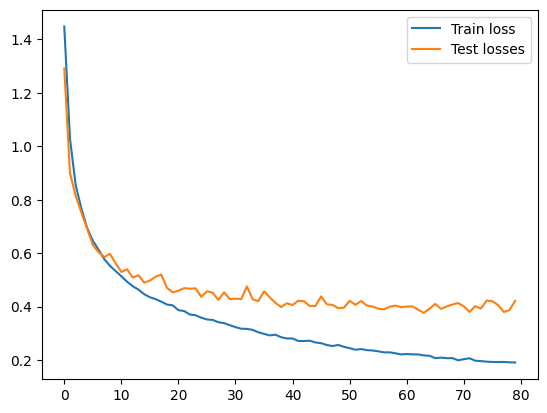

In [120]:
plt.plot(train_losses, label = 'Train loss')
plt.plot(test_losses, label = 'Test losses')
plt.legend()
plt.show()

In [121]:
# Evaluate model accuracy on training and test sets

# -------- Training Accuracy --------
n_correct = 0
n_total = 0

for inputs, targets in train_loader:
    # Move data to device (CPU or GPU)
    inputs, targets = inputs.to(device), targets.to(device)

    # Get model predictions
    outputs = model(inputs)

    # Get predicted class (highest score)
    _, predictions = torch.max(outputs, 1)

    # Count correct predictions
    n_correct += (predictions == targets).sum().item()
    n_total += targets.shape[0]

# Calculate training accuracy
train_acc = n_correct / n_total

# -------- Testing Accuracy --------
n_correct = 0
n_total = 0

for inputs, targets in test_loader:
    inputs, targets = inputs.to(device), targets.to(device)
    outputs = model(inputs)
    _, predictions = torch.max(outputs, 1)
    n_correct += (predictions == targets).sum().item()
    n_total += targets.shape[0]

# Calculate test accuracy
test_acc = n_correct / n_total

# Print results
print(f'Train acc: {train_acc:.4f}, Test acc: {test_acc:.4f}')


Train acc: 0.9376, Test acc: 0.8830


In [122]:
# Plot confusion matrix for classification results
from sklearn.metrics import confusion_matrix
import itertools
import matplotlib.pyplot as plt
import numpy as np

def plot_confusion_matrix(cm, classes, normalize=False, title='Confusion Matrix', cmap=plt.cm.Blues):
    """
    Plots a confusion matrix.

    Parameters:
    - cm: confusion matrix (2D array)
    - classes: list of class labels
    - normalize: whether to normalize values
    - title: title of the plot
    - cmap: color map used for the plot
    """
    
    # Normalize the matrix if requested
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print('Normalized confusion matrix')
    else:
        print('Confusion matrix without normalization')

    print(cm)

    # Display the matrix as an image
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()

    # Set up tick marks and labels
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    # Format each cell
    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment='center',
                 color='white' if cm[i, j] > thresh else 'black')

    # Final layout settings
    plt.tight_layout()
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.show()


Confusion matrix without normalization
[[847   6  40  10   7   2   2   5  71  10]
 [  5 930   1   0   0   1   1   0  19  43]
 [ 13   1 877  29  18  20  28   5   5   4]
 [ 14   2  44 769  30  86  34  11   5   5]
 [  5   3  43  27 865   8  27  16   5   1]
 [  6   0  21  87  23 825  12  25   1   0]
 [  4   1  18  22   7   9 932   3   1   3]
 [  9   0  12  17  30  21   2 897   4   8]
 [ 16   7   4   1   0   4   3   1 958   6]
 [ 10  44   2   3   0   3   3   0  21 914]]


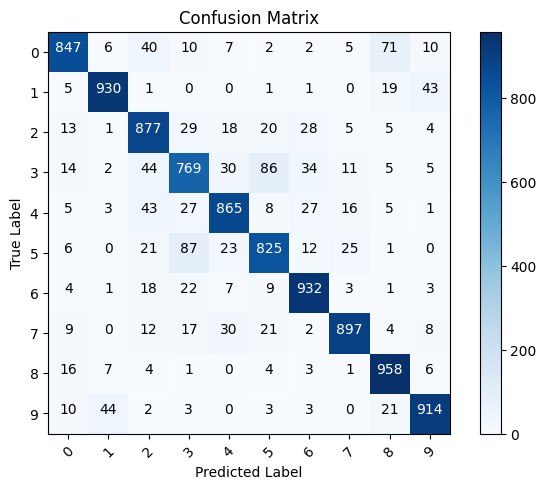

In [123]:
x_test = test_dataset.data
y_test = np.array(test_dataset.targets)
p_test = np.array([])

for inputs, targets in test_loader:
    inputs, targets = inputs.to(device), targets.to(device)
    
    #Forward pass
    outputs = model(inputs)
    
    #Predictions 
    _, predictions = torch.max(outputs, 1)
    
    #Update p_test
    p_test = np.concatenate((p_test, predictions.cpu().numpy()))
    
cm = confusion_matrix(y_test, p_test)
plot_confusion_matrix(cm, list(range(10)))

In [124]:
label = '''airplane
automobile
bird
cat
deer
dog
frog
horse
ship
truck'''.split()

Text(0.5, 1.0, 'Ture label: airplane Predicated: automobile ')

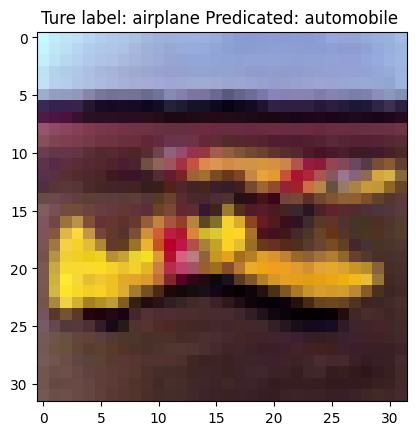

In [133]:
#Misclassified predictions
p_test = p_test.astype(np.uint8)
miss_idx = np.where(p_test != y_test)[0]
i = np.random.choice(miss_idx)
plt.imshow(x_test[i].reshape(32,32,3))
plt.title(f'Ture label: %s Predicated: %s ' % (label[y_test[i]], label[p_test[i]]))